# Research Experiment — ELA + CNN Image Forgery Detection

This notebook implements an **image forgery detection pipeline** using:
- **Error Level Analysis (ELA)** for preprocessing
- A **custom CNN architecture** (3 conv blocks + dense layers) for binary classification

**Task:** Classify images as **Authentic (Au)** or **Tampered (Tp)** using the CASIA v2.0 dataset.

---

| Parameter | Value |
|-----------|-------|
| **Image Size** | 150 × 150 |
| **ELA Quality** | 90 (JPEG recompression) |
| **Batch Size** | 8 |
| **Epochs** | 40 |
| **Optimizer** | Adam (lr=0.0001) |
| **Loss** | Binary Crossentropy |
| **Architecture** | Conv(64) → Conv(128) → Conv(256) → Dense(512) → Dense(2) |
| **Dataset** | CASIA v2.0 (Au + Tp) |

In [1]:
# ============================================================
# 1. ENVIRONMENT SETUP
# ============================================================

import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.utils import to_categorical, plot_model

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.utils import shuffle

# Image processing
from PIL import Image, ImageChops, ImageEnhance

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-03-15 06:42:38.064409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773556958.265460      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773556958.321784      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773556958.759730      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773556958.759772      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773556958.759775      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True


## 2. Dataset Setup

The **CASIA v2.0** dataset contains:

```
dataset/
 ├── Au/    # Authentic images
 └── Tp/    # Tampered images
```

- **Au (Authentic):** Unmanipulated original images → label `1`
- **Tp (Tampered):** Manipulated/forged images → label `0`

In [2]:
# ============================================================
# 2. DATASET CONFIGURATION
# ============================================================

IMAGE_SIZE = (150, 150)
ELA_QUALITY = 90
BATCH_SIZE = 8
EPOCHS = 40

# ============================================================
# Auto-discover CASIA dataset path on Kaggle
# ============================================================
def find_dataset():
    """Walk /kaggle/input/ to find a directory containing both Au/ and Tp/ subdirs."""
    search_root = '/kaggle/input'
    for root, dirs, _ in os.walk(search_root):
        if 'Au' in dirs and 'Tp' in dirs:
            return root
        if root.count(os.sep) - search_root.count(os.sep) > 3:
            continue
    return None

DATASET_PATH = find_dataset()
if DATASET_PATH is None:
    raise FileNotFoundError(
        'Could not find CASIA dataset (directory with Au/ and Tp/ subdirs) '
        'under /kaggle/input/. Check that the dataset is attached to this notebook.'
    )

AU_PATH = os.path.join(DATASET_PATH, 'Au')
TP_PATH = os.path.join(DATASET_PATH, 'Tp')

# Discover what file types actually exist in the dataset
def get_image_files(directory):
    """Return list of all image file paths in a directory (any common format)."""
    IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp', '.gif'}
    files = []
    for dirpath, _, filenames in os.walk(directory):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS:
                files.append(os.path.join(dirpath, f))
    return files

au_files = get_image_files(AU_PATH)
tp_files = get_image_files(TP_PATH)

# Show what was found
au_exts = set(os.path.splitext(f)[1].lower() for f in au_files)
tp_exts = set(os.path.splitext(f)[1].lower() for f in tp_files)

print(f'Dataset found: {DATASET_PATH}')
print(f'Image size:    {IMAGE_SIZE}')
print(f'ELA quality:   {ELA_QUALITY}')
print(f'Batch size:    {BATCH_SIZE}')
print(f'Epochs:        {EPOCHS}')
print(f'\nAuthentic (Au): {len(au_files)} images  {au_exts}')
print(f'Tampered  (Tp): {len(tp_files)} images  {tp_exts}')

Dataset found: /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK
Image size:    (150, 150)
ELA quality:   90
Batch size:    8
Epochs:        40

Authentic (Au): 7491 images  {'.png'}
Tampered  (Tp): 5123 images  {'.png'}


## 3. ELA (Error Level Analysis) Conversion

**Error Level Analysis** detects image manipulation by examining compression artifacts:

1. Re-save the image at a known JPEG quality level
2. Compute the pixel-wise difference between original and re-saved
3. Normalize the difference to enhance visibility

**Why it works:** Manipulated regions have different compression histories than the rest of the image, producing different error levels when re-compressed.

In [3]:
# ============================================================
# 3. ELA CONVERSION FUNCTIONS
# ============================================================

def convert_to_ela_image(path, quality):
    """Convert an image to its ELA (Error Level Analysis) representation.
    
    Args:
        path: Path to the input image
        quality: JPEG recompression quality (0-100)
    
    Returns:
        PIL Image of the ELA result, or None on error
    """
    temp_filename = 'temp_file.jpg'
    
    try:
        # Open and ensure RGB
        image = Image.open(path).convert('RGB')
        
        # Re-save at specified quality
        image.save(temp_filename, 'JPEG', quality=quality)
        temp_image = Image.open(temp_filename)
        
        # Compute pixel-wise difference
        ela_image = ImageChops.difference(image, temp_image)
        
        # Normalize brightness to [0, 255]
        extrema = ela_image.getextrema()
        max_diff = max([ex[1] for ex in extrema])
        if max_diff == 0:
            max_diff = 1
        scale = 255.0 / max_diff
        
        ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
        
        return ela_image
    except Exception as e:
        print(f'Could not convert {path} to ELA: {str(e)}')
        return None


def prepare_image(image_path):
    """Convert an image to ELA, resize, flatten, and normalize."""
    ela = convert_to_ela_image(image_path, ELA_QUALITY)
    if ela is None:
        return None
    return np.array(ela.resize(IMAGE_SIZE)).flatten() / 255.0


print('ELA functions defined.')

ELA functions defined.


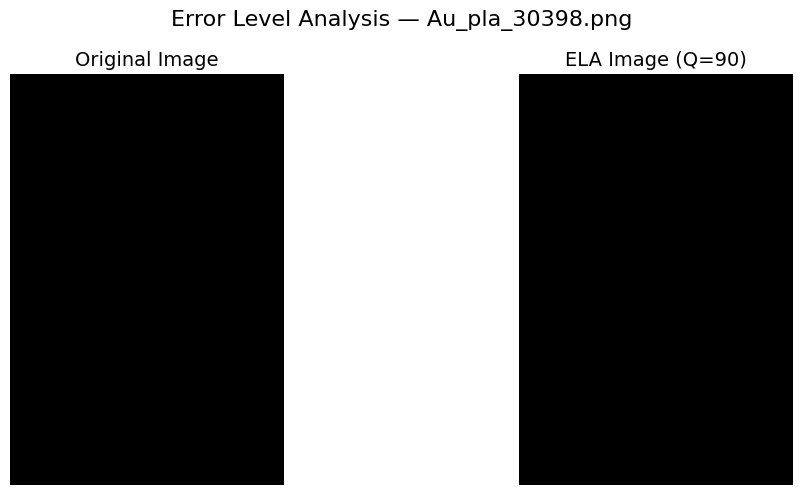

In [4]:
# ============================================================
# 3.1 ELA VISUALIZATION
# ============================================================

if au_files:
    sample_image = au_files[0]
    original = Image.open(sample_image).convert('RGB')
    ela = convert_to_ela_image(sample_image, ELA_QUALITY)

    if ela is not None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(original)
        axes[0].set_title('Original Image', fontsize=14)
        axes[0].axis('off')

        axes[1].imshow(ela)
        axes[1].set_title(f'ELA Image (Q={ELA_QUALITY})', fontsize=14)
        axes[1].axis('off')

        plt.suptitle(f'Error Level Analysis — {os.path.basename(sample_image)}', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print(f'ELA conversion failed for: {sample_image}')
else:
    print('No authentic images found for visualization.')

## 4. Dataset Preparation

Load images from both directories:
- **Au (Authentic)** → label `1`
- **Tp (Tampered)** → label `0`

Each image is converted to its ELA representation, resized, flattened, and normalized to `[0, 1]`.
Labels are one-hot encoded: `[1, 0]` = Tampered, `[0, 1]` = Authentic.

In [5]:
# ============================================================
# 4. LOAD AND PREPARE DATASET
# ============================================================

X = []  # ELA-converted images (flattened)
Y = []  # Labels: 1 = authentic, 0 = tampered

# --- Load Authentic images (label = 1) ---
print(f'Loading Authentic (Au) images... ({len(au_files)} found)')
au_loaded = 0
for full_path in au_files:
    img = prepare_image(full_path)
    if img is not None:
        X.append(img)
        Y.append(1)
        au_loaded += 1
    if au_loaded % 500 == 0 and au_loaded > 0:
        print(f'  Processed {au_loaded} authentic images...')

print(f'Authentic images loaded: {au_loaded}')

# --- Load Tampered images (label = 0) ---
print(f'\nLoading Tampered (Tp) images... ({len(tp_files)} found)')
tp_loaded = 0
for full_path in tp_files:
    img = prepare_image(full_path)
    if img is not None:
        X.append(img)
        Y.append(0)
        tp_loaded += 1
    if tp_loaded % 500 == 0 and tp_loaded > 0:
        print(f'  Processed {tp_loaded} tampered images...')

print(f'Tampered images loaded: {tp_loaded}')

# --- Sanity check ---
total = len(X)
if total == 0:
    raise RuntimeError(
        f'No images were loaded! Au path: {AU_PATH}, Tp path: {TP_PATH}. '
        f'Files found: Au={len(au_files)}, Tp={len(tp_files)}. '
        'Check that PIL can open these files (perhaps unsupported format?).'
    )

# --- Shuffle dataset (X and Y together) ---
X, Y = shuffle(X, Y, random_state=SEED)

# --- Convert to numpy arrays ---
X = np.array(X)
Y = to_categorical(Y, 2)  # One-hot encoding: [tampered, authentic]
X = X.reshape(-1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)

# --- Print dataset distribution ---
print(f'\n--- Dataset Summary ---')
print(f'Total samples: {total}')
print(f'  Authentic: {au_loaded} ({au_loaded/total*100:.1f}%)')
print(f'  Tampered:  {tp_loaded} ({tp_loaded/total*100:.1f}%)')
print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')

Loading Authentic (Au) images... (7491 found)
  Processed 500 authentic images...
  Processed 1000 authentic images...
  Processed 1500 authentic images...
  Processed 2000 authentic images...
  Processed 2500 authentic images...
  Processed 3000 authentic images...
  Processed 3500 authentic images...
  Processed 4000 authentic images...
  Processed 4500 authentic images...
  Processed 5000 authentic images...
  Processed 5500 authentic images...
  Processed 6000 authentic images...
  Processed 6500 authentic images...
  Processed 7000 authentic images...
Authentic images loaded: 7491

Loading Tampered (Tp) images... (5123 found)
  Processed 500 tampered images...
  Processed 1000 tampered images...
  Processed 1500 tampered images...
  Processed 2000 tampered images...
  Processed 2500 tampered images...
  Processed 3000 tampered images...
  Processed 3500 tampered images...
  Processed 4000 tampered images...
  Processed 4500 tampered images...
  Processed 5000 tampered images...
Ta

## 5. Train / Validation / Test Split

Split the dataset into three partitions:
- **70%** Training
- **15%** Validation
- **15%** Test

In [6]:
# ============================================================
# 5. TRAIN / VALIDATION / TEST SPLIT (70 / 15 / 15)
# ============================================================

# First split: 70% train, 30% temp
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=SEED
)

# Second split: 50/50 on the 30% → 15% val, 15% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=SEED
)

# Free memory
del X, Y, X_temp, Y_temp

print(f'Training set:   X={X_train.shape}, Y={Y_train.shape}')
print(f'Validation set: X={X_val.shape},   Y={Y_val.shape}')
print(f'Test set:       X={X_test.shape},   Y={Y_test.shape}')

Training set:   X=(8829, 150, 150, 3), Y=(8829, 2)
Validation set: X=(1892, 150, 150, 3),   Y=(1892, 2)
Test set:       X=(1893, 150, 150, 3),   Y=(1893, 2)


## 6. CNN Architecture (Experimental)

A deeper CNN with batch normalization for image-level forgery classification:

```
Input (150×150×3)
    │
    ├── Conv2D(64, 3×3, ReLU) → BatchNorm → MaxPool(2×2)
    ├── Conv2D(128, 3×3, ReLU) → BatchNorm → MaxPool(2×2)
    ├── Conv2D(256, 3×3, ReLU) → BatchNorm → MaxPool(2×2)
    │
    ├── Dropout(0.5) → Flatten
    ├── Dense(512, ReLU) → Dropout(0.5)
    │
    └── Dense(2, Sigmoid) → [Tampered, Authentic]
```

In [7]:
# ============================================================
# 6. BUILD CNN MODEL
# ============================================================

def build_model():
    model = Sequential()
    
    # Block 1
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='valid',
                     activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    
    # Block 2
    model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='valid', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    
    # Block 3
    model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='valid', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(2, 2)))
    
    # Regularization + Flatten
    model.add(Dropout(0.5))
    model.add(Flatten())
    
    # Fully connected
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    
    # Output layer: 2 classes (tampered, authentic)
    model.add(Dense(2, activation='sigmoid'))
    
    return model


model = build_model()

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773557168.311459      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    37,880,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,253,954 (145.93 MB)

 Trainable params: 38,253,058 (145.92 MB)

 Non-trainable params: 896 (3.50 KB)

## 7. Training

Train for up to **40 epochs** with early stopping on validation accuracy (patience=2).

In [8]:
# ============================================================
# 7. TRAIN THE MODEL
# ============================================================

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    mode='max'
)

history = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping],
    verbose=1
)

print(f'\nTraining complete. Stopped at epoch {len(history.history["loss"])}/{EPOCHS}')

Epoch 1/40


I0000 00:00:1773557178.981844     128 service.cc:152] XLA service 0x7e1b0c012410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773557178.981896     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773557179.579301     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


   9/1104 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7751 - loss: 0.3250 - precision: 0.7882 - recall: 0.7647 

I0000 00:00:1773557184.836232     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1104/1104 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9497 - loss: 1.6069 - precision: 0.9371 - recall: 0.9503 - val_accuracy: 0.9979 - val_loss: 0.0116 - val_precision: 0.9974 - val_recall: 0.9958
Epoch 2/40
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9989 - loss: 0.0188 - precision: 0.9980 - recall: 0.9976 - val_accuracy: 0.9984 - val_loss: 0.0071 - val_precision: 0.9974 - val_recall: 0.9995
Epoch 3/40
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9996 - loss: 0.0087 - precision: 0.9988 - recall: 0.9994 - val_accuracy: 0.9979 - val_loss: 0.0099 - val_precision: 0.9984 - val_recall: 0.9979
Epoch 4/40
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9996 - loss: 0.0155 - precision: 0.9984 - recall: 0.9985 - val_accuracy: 1.0000 - val_loss: 0.0023 - val_precision: 0.9979 - val_recall: 1.0000
Epoch 5/40
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9989 - loss: 0.0242 - precision: 0.9976 - recall: 0.9972 - val_accuracy: 0.9995 - val

## 8. Evaluation

Evaluate the trained model on the held-out test set.

**Metrics computed:**
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [9]:
# ============================================================
# 8. EVALUATE ON TEST SET
# ============================================================

# Keras evaluation
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test, verbose=0)

# Predictions
y_pred_proba = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_proba, axis=1)
y_true_labels = np.argmax(Y_test, axis=1)

# Sklearn metrics (more reliable for F1)
sk_accuracy = accuracy_score(y_true_labels, y_pred_labels)
sk_precision = precision_score(y_true_labels, y_pred_labels, average='weighted')
sk_recall = recall_score(y_true_labels, y_pred_labels, average='weighted')
sk_f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Print results
print('=' * 50)
print('         TEST SET EVALUATION RESULTS')
print('=' * 50)
print(f'  Loss:      {loss:.4f}')
print(f'  Accuracy:  {sk_accuracy:.4f} ({sk_accuracy*100:.2f}%)')
print(f'  Precision: {sk_precision:.4f}')
print(f'  Recall:    {sk_recall:.4f}')
print(f'  F1 Score:  {sk_f1:.4f}')
print('=' * 50)

print('\nClassification Report:')
print(classification_report(
    y_true_labels, y_pred_labels,
    target_names=['Tampered', 'Authentic']
))

print('Confusion Matrix:')
print(cm)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
         TEST SET EVALUATION RESULTS
  Loss:      0.0071
  Accuracy:  0.9995 (99.95%)
  Precision: 0.9995
  Recall:    0.9995
  F1 Score:  0.9995

Classification Report:
              precision    recall  f1-score   support

    Tampered       1.00      1.00      1.00       777
   Authentic       1.00      1.00      1.00      1116

    accuracy                           1.00      1893
   macro avg       1.00      1.00      1.00      1893
weighted avg       1.00      1.00      1.00      1893

Confusion Matrix:
[[ 776    1]
 [   0 1116]]


## 9. Visualization

Training curves and confusion matrix.

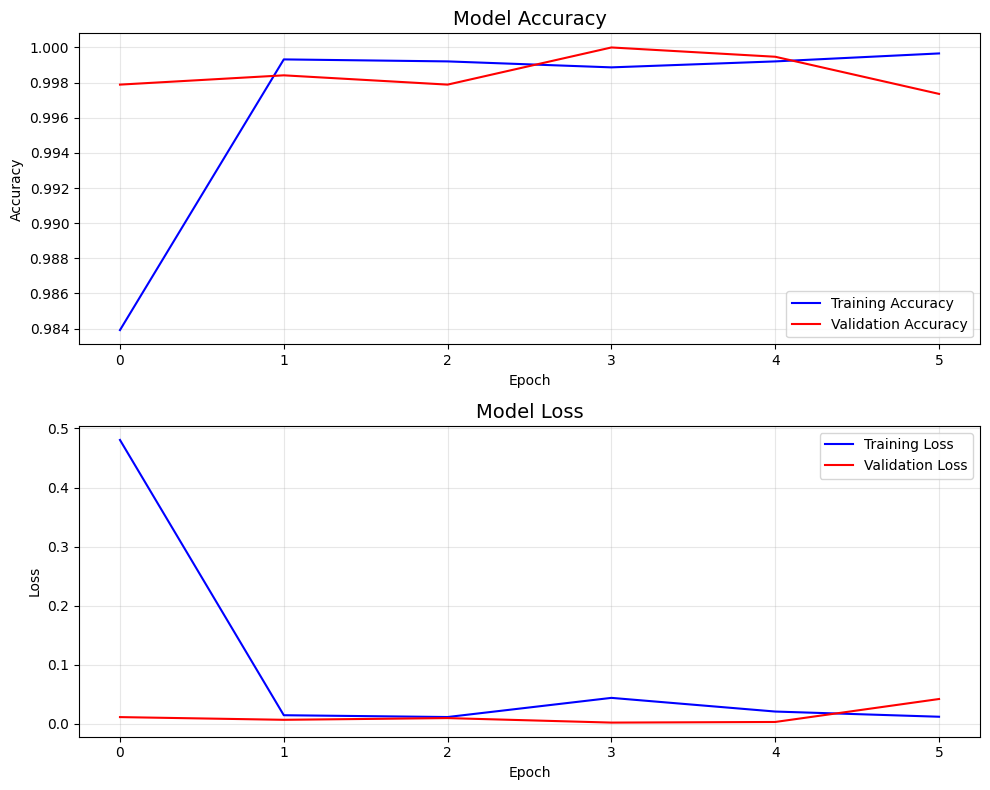

In [10]:
# ============================================================
# 9.1 TRAINING CURVES
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Accuracy
ax1.plot(history.history['accuracy'], 'b-', label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy')
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], 'b-', label='Training Loss')
ax2.plot(history.history['val_loss'], 'r-', label='Validation Loss')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

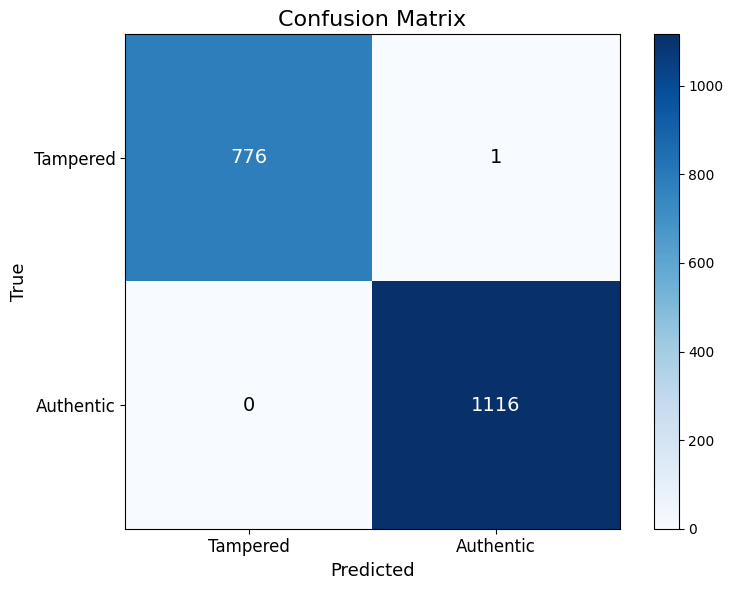

In [11]:
# ============================================================
# 9.2 CONFUSION MATRIX HEATMAP
# ============================================================

class_names = ['Tampered', 'Authentic']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix', fontsize=16)
plt.colorbar(im, ax=ax)

# Tick labels
tick_marks = np.arange(len(class_names))
ax.set_xticks(tick_marks)
ax.set_xticklabels(class_names, fontsize=12)
ax.set_yticks(tick_marks)
ax.set_yticklabels(class_names, fontsize=12)

# Annotate cells with counts
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > thresh else 'black')

ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Model Export

Save the trained model and export the architecture diagram.

In [12]:
# ============================================================
# 10. SAVE MODEL & ARCHITECTURE
# ============================================================

# Save full model (weights + architecture + optimizer state)
model.save('tampering_model.h5')
print('Model saved to: tampering_model.h5')

# Export architecture diagram
try:
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
    print('Architecture diagram saved to: model_architecture.png')
except Exception as e:
    print(f'Could not export architecture diagram: {e}')
    print('(This requires pydot and graphviz to be installed)')

Model saved to: tampering_model.h5
Architecture diagram saved to: model_architecture.png


## Bonus: Experiment Comparison

Log the results from this experiment for comparison across runs.

In [13]:
# ============================================================
# BONUS: EXPERIMENT METRICS LOG
# ============================================================

# Experiment metadata
experiment = {
    'name': 'ELA + Deeper CNN (3 Conv Blocks)',
    'image_size': IMAGE_SIZE,
    'ela_quality': ELA_QUALITY,
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(history.history['loss']),
    'epochs_max': EPOCHS,
    'optimizer': 'Adam (lr=0.0001)',
    'loss_fn': 'binary_crossentropy',
    'architecture': 'Conv64-BN-Pool → Conv128-BN-Pool → Conv256-BN-Pool → Dense512 → Dense2',
    'test_accuracy': sk_accuracy,
    'test_precision': sk_precision,
    'test_recall': sk_recall,
    'test_f1': sk_f1,
    'test_loss': loss,
}

# Pretty-print experiment log
print('\n' + '=' * 60)
print('           EXPERIMENT RESULTS LOG')
print('=' * 60)
print(f'| {"Metric":<25} | {"Value":<28} |')
print(f'|{"-"*27}|{"-"*30}|')
for key, val in experiment.items():
    if isinstance(val, float):
        print(f'| {key:<25} | {val:<28.4f} |')
    else:
        print(f'| {key:<25} | {str(val):<28} |')
print('=' * 60)

print('\nTo compare with other experiments, run this notebook with ')
print('different hyperparameters and log results in a shared table.')


           EXPERIMENT RESULTS LOG
| Metric                    | Value                        |
|---------------------------|------------------------------|
| name                      | ELA + Deeper CNN (3 Conv Blocks) |
| image_size                | (150, 150)                   |
| ela_quality               | 90                           |
| batch_size                | 8                            |
| epochs_trained            | 6                            |
| epochs_max                | 40                           |
| optimizer                 | Adam (lr=0.0001)             |
| loss_fn                   | binary_crossentropy          |
| architecture              | Conv64-BN-Pool → Conv128-BN-Pool → Conv256-BN-Pool → Dense512 → Dense2 |
| test_accuracy             | 0.9995                       |
| test_precision            | 0.9995                       |
| test_recall               | 0.9995                       |
| test_f1                   | 0.9995                       |
| te